In [31]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FormatStrFormatter

In [32]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [33]:
resultsFileName = 'Economics overall.xlsx'

In [34]:
df = pd.read_excel(os.path.join('..', 'Results', resultsFileName), sheet_name = 'Overall', index_col = 0)
df_new = df[df['Year'] == 2022]
total = df_new['Total']
df_new = df_new.drop(columns = 'Year')
df_new = df_new.drop(columns = 'Total')
df_new = df_new.reset_index(drop = True)

In [35]:
xPts = np.arange(0, len(df_new))
xLabels = []
for i in range(0, len(xPts)):
    string = df['Scenario'][i]
    string = string.replace(' ', '\n')
    xLabels.append(string)
    

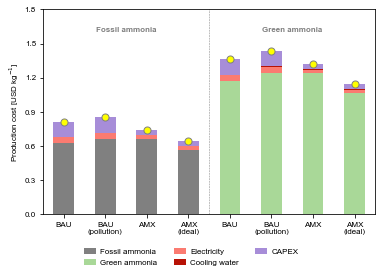

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (fig_length[1.5], fig_height*0.35))

colors = ['#808080', '#a9d898', '#fb7b71', '#b71205', '#a78dd8']

df_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)

ax.legend([], frameon = False)

ax.set_ylabel('Production cost [USD kg$^\mathrm{-1}$]')

ax.set_xticks(xPts)  
ax.set_xticklabels(xLabels, rotation = 0, ha = 'center')  

ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax.set_ylim([0, 1.8])
ax.yaxis.set_major_locator(MaxNLocator(6))

ax.text(1.5, 1.6, 'Fossil ammonia', ha = 'center', color = '#808080', fontweight = 'bold')
ax.text(5.5, 1.6, 'Green ammonia', ha = 'center', color = '#808080', fontweight = 'bold')
ax.scatter(xPts, total, s = 50, facecolor = 'yellow', edgecolors = '#808080')

# for i in range(0, len(df_new)):
#     if i > 1 and i < 4:
#         ax.errorbar(i, df_new.iloc[i, 1:].sum(), yerr = [[yerr[0][i]], [yerr[1][i]]], fmt = 'none', color = '#808080', capsize = 1.5, elinewidth = 0.25)
#     elif i > 5:
#         ax.errorbar(i, df_new.iloc[i, 1:].sum(), yerr = [[yerr[0][i]], [yerr[1][i]]], fmt = 'none', color = '#808080', capsize = 1.5, elinewidth = 0.25)

handles, labels = ax.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.12), frameon = False, ncol = 3, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Economics overall')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200, facecolor = 'white')
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200, facecolor = 'white')